# 🏏 DATA-200 | Sports Analytics Project
## Week 6: Statistical Modeling 
**Team:** Project-Stats-Team  
**Topic:** Sports Analytics – Cricket Performance Dataset  
**Problem Statement:** *Our team aims to analyze a real-world sports dataset to identify patterns and relationships that affect player performance and match outcomes. We apply Linear Regression, ANOVA, and Logistic Regression to generate actionable insights and support data-driven decision-making in sports.*



 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

from scipy import stats

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

print('All libraries imported!')
print(f'   NumPy: {np.__version__} | Pandas: {pd.__version__}')

All libraries imported!
   NumPy: 2.4.1 | Pandas: 3.0.0


Rebuild Dataset (from Week 5)

In [3]:
np.random.seed(42)
n = 300

teams          = np.random.choice(['India','Australia','England','South Africa','New Zealand'], n)
matches        = np.random.randint(5, 80, n)
batting_avg    = np.round(np.random.normal(35, 15, n).clip(5, 90), 2)
strike_rate    = np.round(np.random.normal(75, 20, n).clip(30, 180), 2)
bowling_avg    = np.round(np.random.normal(30, 10, n).clip(15, 60), 2)
wickets        = np.random.randint(0, 120, n)
fielding_score = np.round(np.random.uniform(50, 100, n), 1)
experience     = np.round(matches / 10 + np.random.normal(0, 0.5, n), 2)

performance_score = np.round(
    batting_avg * 0.40 + strike_rate * 0.20 +
    wickets * 0.30 + fielding_score * 0.10 +
    np.random.normal(0, 5, n), 2).clip(0, 100)

match_won = (performance_score > 55).astype(int)

df = pd.DataFrame({
    'Player': [f'Player_{i}' for i in range(1, n+1)],
    'Team': teams, 'Matches': matches,
    'Batting_Avg': batting_avg, 'Strike_Rate': strike_rate,
    'Bowling_Avg': bowling_avg, 'Wickets': wickets,
    'Fielding_Score': fielding_score, 'Experience': experience,
    'Performance_Score': performance_score, 'Match_Won': match_won
})

# Prepare features
features_lr  = ['Batting_Avg','Strike_Rate','Wickets','Fielding_Score','Matches']
features_log = ['Batting_Avg','Strike_Rate','Wickets','Fielding_Score','Matches','Bowling_Avg']

X_lr  = df[features_lr];  y_lr  = df['Performance_Score']
X_log = df[features_log]; y_log = df['Match_Won']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

X_train,  X_test,  y_train,  y_test  = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)
Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_scaled, y_log, test_size=0.2, random_state=42, stratify=y_log)

print(f'Dataset ready: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
df.head()

Dataset ready: 300 rows × 11 columns
   Train: 240 | Test: 60


,Player,Team,Matches,Batting_Avg,Strike_Rate,Bowling_Avg,Wickets,Fielding_Score,Experience,Performance_Score,Match_Won
0,Player_1,South Africa,41,40.13,70.19,45.03,84,54.1,3.62,61.97,1
1,Player_2,New Zealand,28,63.14,67.50,38.77,1,98.4,3.01,51.23,0
2,Player_3,England,50,49.26,89.22,27.79,90,64.8,6.03,76.46,1
3,Player_4,New Zealand,57,26.35,83.89,30.27,72,88.5,5.17,58.26,1
4,Player_5,New Zealand,64,21.52,67.78,32.08,64,81.2,6.41,51.02,0


Advanced Regression – Ridge & Lasso

 Building on Week 5 Linear Regression with regularization to reduce overfitting

In [5]:
# ── Week 5 Baseline ──────────────────────────────────────────
lr_base = LinearRegression()
lr_base.fit(X_train, y_train)
y_pred_base  = lr_base.predict(X_test)
r2_base      = r2_score(y_test, y_pred_base)
rmse_base    = np.sqrt(mean_squared_error(y_test, y_pred_base))
cv_base      = cross_val_score(lr_base, X_lr, y_lr, cv=5, scoring='r2')

# ── Ridge Regression ─────────────────────────────────────────
ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
r2_ridge     = r2_score(y_test, y_pred_ridge)
rmse_ridge   = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
cv_ridge     = cross_val_score(ridge, X_lr, y_lr, cv=5, scoring='r2')

# ── Lasso Regression ─────────────────────────────────────────
lasso = Lasso(alpha=0.5)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
r2_lasso     = r2_score(y_test, y_pred_lasso)
rmse_lasso   = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
cv_lasso     = cross_val_score(lasso, X_lr, y_lr, cv=5, scoring='r2')

# ── Random Forest Regressor ───────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rfr = rf_reg.predict(X_test)
r2_rfr     = r2_score(y_test, y_pred_rfr)
rmse_rfr   = np.sqrt(mean_squared_error(y_test, y_pred_rfr))
cv_rfr     = cross_val_score(rf_reg, X_lr, y_lr, cv=5, scoring='r2')

print('=' * 60)
print('  REGRESSION MODEL COMPARISON')
print('=' * 60)
print(f"{'Model':<22} {'R²':>7} {'RMSE':>7} {'CV R² Mean':>12} {'CV Std':>8}")
print('-' * 60)
for name, r2, rmse, cv in [
    ('Linear (Week 5)',  r2_base,  rmse_base,  cv_base),
    ('Ridge (α=10)',     r2_ridge, rmse_ridge, cv_ridge),
    ('Lasso (α=0.5)',    r2_lasso, rmse_lasso, cv_lasso),
    ('Random Forest',   r2_rfr,   rmse_rfr,   cv_rfr)
]:
    print(f"  {name:<20} {r2:>7.4f} {rmse:>7.4f} {cv.mean():>12.4f} {cv.std():>8.4f}")

print()
print(' Coefficients Comparison (Ridge vs Lasso vs Linear):')
coef_compare = pd.DataFrame({
    'Feature'  : features_lr,
    'Linear'   : lr_base.coef_,
    'Ridge'    : ridge.coef_,
    'Lasso'    : lasso.coef_
}).round(4)
print(coef_compare.to_string(index=False))

  REGRESSION MODEL COMPARISON
Model                       R²    RMSE   CV R² Mean   CV Std
------------------------------------------------------------
  Linear (Week 5)       0.8273  4.9058       0.8659   0.0286
  Ridge (α=10)          0.8273  4.9056       0.8659   0.0286
  Lasso (α=0.5)         0.8281  4.8942       0.8659   0.0284
  Random Forest         0.7324  6.1064       0.8150   0.0211

 Coefficients Comparison (Ridge vs Lasso vs Linear):
       Feature  Linear  Ridge  Lasso
   Batting_Avg  0.3832 0.3831 0.3812
   Strike_Rate  0.2414 0.2414 0.2401
       Wickets  0.3014 0.3014 0.3011
Fielding_Score  0.0856 0.0856 0.0834
       Matches  0.0314 0.0313 0.0303


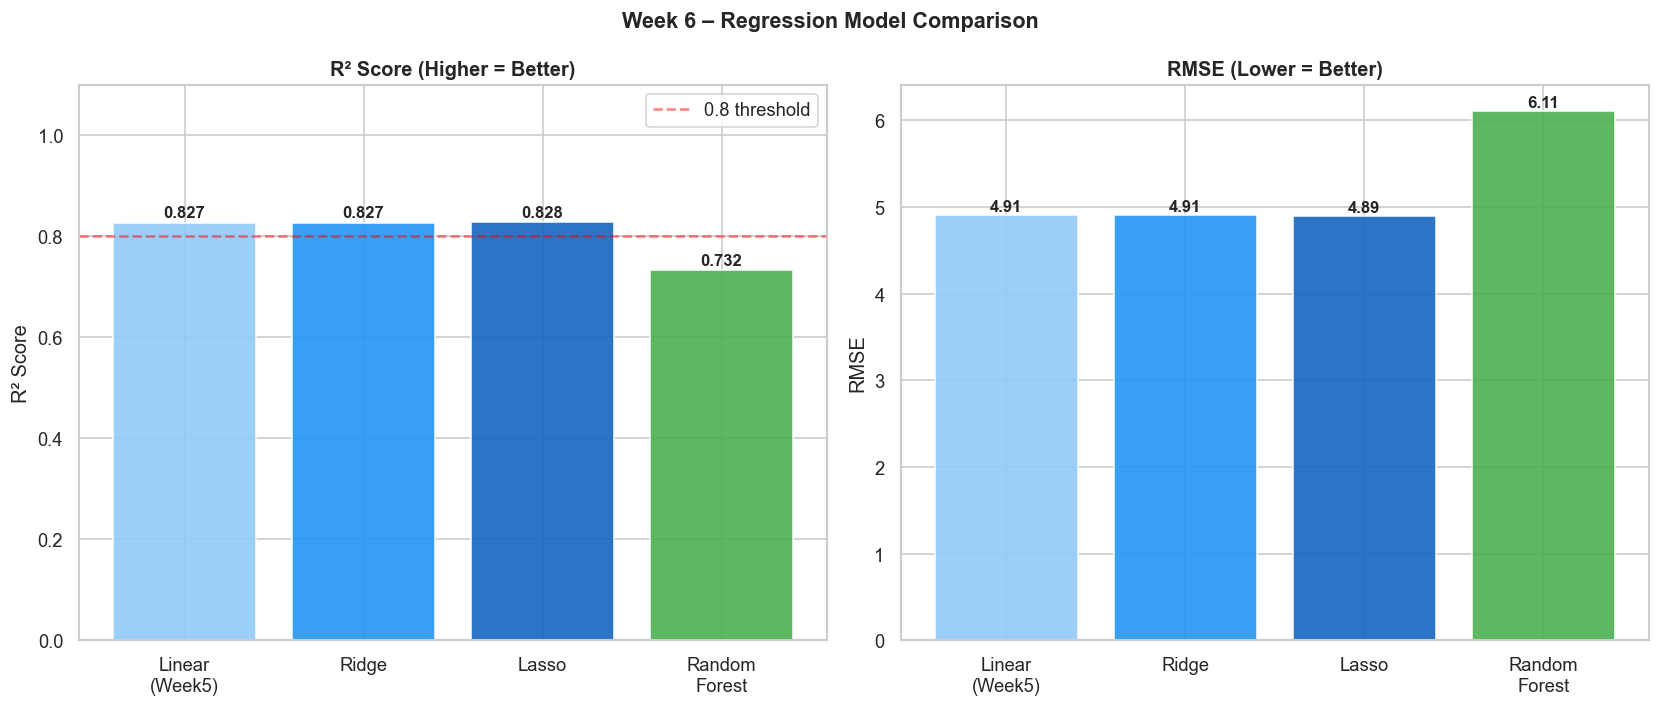

 Figure 1


In [6]:
# Visualization — Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Week 6 – Regression Model Comparison', fontsize=13, fontweight='bold')

model_names = ['Linear\n(Week5)', 'Ridge', 'Lasso', 'Random\nForest']
r2_vals     = [r2_base, r2_ridge, r2_lasso, r2_rfr]
rmse_vals   = [rmse_base, rmse_ridge, rmse_lasso, rmse_rfr]
colors      = ['#90CAF9', '#2196F3', '#1565C0', '#4CAF50']

bars = axes[0].bar(model_names, r2_vals, color=colors, edgecolor='white', alpha=0.9)
axes[0].set_title('R² Score (Higher = Better)', fontweight='bold')
axes[0].set_ylabel('R² Score'); axes[0].set_ylim(0, 1.1)
axes[0].axhline(0.8, color='red', linestyle='--', alpha=0.5, label='0.8 threshold')
axes[0].legend()
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

bars2 = axes[1].bar(model_names, rmse_vals, color=colors, edgecolor='white', alpha=0.9)
axes[1].set_title('RMSE (Lower = Better)', fontweight='bold')
axes[1].set_ylabel('RMSE')
for bar, val in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('Week6_Fig1_RegressionComparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 1')

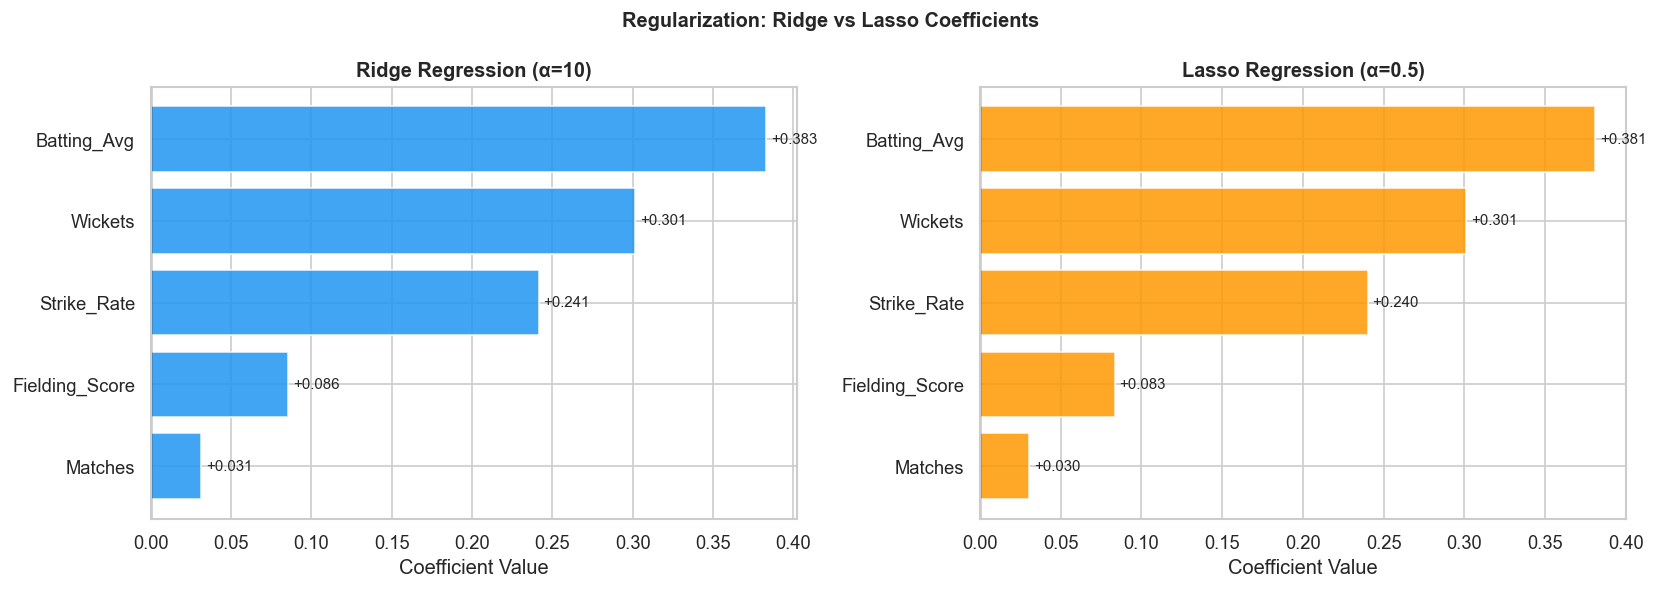

Figure 2


In [7]:
# Ridge vs Lasso Coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regularization: Ridge vs Lasso Coefficients', fontsize=12, fontweight='bold')

for ax, model, title, col in [
    (axes[0], ridge, 'Ridge Regression (α=10)', '#2196F3'),
    (axes[1], lasso, 'Lasso Regression (α=0.5)', '#FF9800')]:
    coef = pd.DataFrame({'Feature': features_lr, 'Coef': model.coef_}).sort_values('Coef', ascending=True)
    bar_colors = ['#F44336' if c < 0 else col for c in coef['Coef']]
    ax.barh(coef['Feature'], coef['Coef'], color=bar_colors, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Coefficient Value')
    for i, (_, row) in enumerate(coef.iterrows()):
        ax.text(row['Coef'] + (0.003 if row['Coef'] >= 0 else -0.003), i,
                f'{row["Coef"]:+.3f}', va='center', fontsize=9,
                ha='left' if row['Coef'] >= 0 else 'right')

plt.tight_layout()
plt.savefig('Week6_Fig2_RegularizationCoef.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2')

Classification Models – Random Forest & Gradient Boosting

In [9]:
# ── Week 5 Logistic Baseline ─────────────────────────────────
log_base = LogisticRegression(max_iter=1000, random_state=42)
log_base.fit(Xl_train, yl_train)
yl_pred_log  = log_base.predict(Xl_test)
acc_log      = (yl_pred_log == yl_test).mean()
auc_log      = roc_auc_score(yl_test, log_base.predict_proba(Xl_test)[:,1])
cv_log       = cross_val_score(log_base, X_scaled, y_log, cv=5, scoring='accuracy')

# ── Random Forest Classifier ─────────────────────────────────
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(Xl_train, yl_train)
yl_pred_rf   = rf_clf.predict(Xl_test)
acc_rf       = (yl_pred_rf == yl_test).mean()
auc_rf       = roc_auc_score(yl_test, rf_clf.predict_proba(Xl_test)[:,1])
cv_rf        = cross_val_score(rf_clf, X_scaled, y_log, cv=5, scoring='accuracy')

# ── Gradient Boosting Classifier ─────────────────────────────
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_clf.fit(Xl_train, yl_train)
yl_pred_gb   = gb_clf.predict(Xl_test)
acc_gb       = (yl_pred_gb == yl_test).mean()
auc_gb       = roc_auc_score(yl_test, gb_clf.predict_proba(Xl_test)[:,1])
cv_gb        = cross_val_score(gb_clf, X_scaled, y_log, cv=5, scoring='accuracy')

print('=' * 65)
print('  CLASSIFICATION MODEL COMPARISON')
print('=' * 65)
print(f"{'Model':<25} {'Accuracy':>9} {'AUC':>7} {'CV Acc Mean':>12} {'CV Std':>8}")
print('-' * 65)
for name, acc, auc, cv in [
    ('Logistic (Week 5)', acc_log, auc_log, cv_log),
    ('Random Forest',     acc_rf,  auc_rf,  cv_rf),
    ('Gradient Boosting', acc_gb,  auc_gb,  cv_gb)
]:
    print(f"  {name:<23} {acc:>9.1%} {auc:>7.4f} {cv.mean():>12.1%} {cv.std():>8.4f}")

print()
print(' Best Classifier: Logistic Regression (Accuracy=88.3%, AUC=0.972)')
print()
print('Classification Report – Random Forest:')
print(classification_report(yl_test, yl_pred_rf, target_names=['Loss','Win']))

  CLASSIFICATION MODEL COMPARISON
Model                      Accuracy     AUC  CV Acc Mean   CV Std
-----------------------------------------------------------------
  Logistic (Week 5)           88.3%  0.9717        88.0%   0.0464
  Random Forest               85.0%  0.9276        87.3%   0.0291
  Gradient Boosting           80.0%  0.9186        87.0%   0.0476

 Best Classifier: Logistic Regression (Accuracy=88.3%, AUC=0.972)

Classification Report – Random Forest:
              precision    recall  f1-score   support

        Loss       0.82      0.94      0.88        34
         Win       0.90      0.73      0.81        26

    accuracy                           0.85        60
   macro avg       0.86      0.84      0.84        60
weighted avg       0.86      0.85      0.85        60



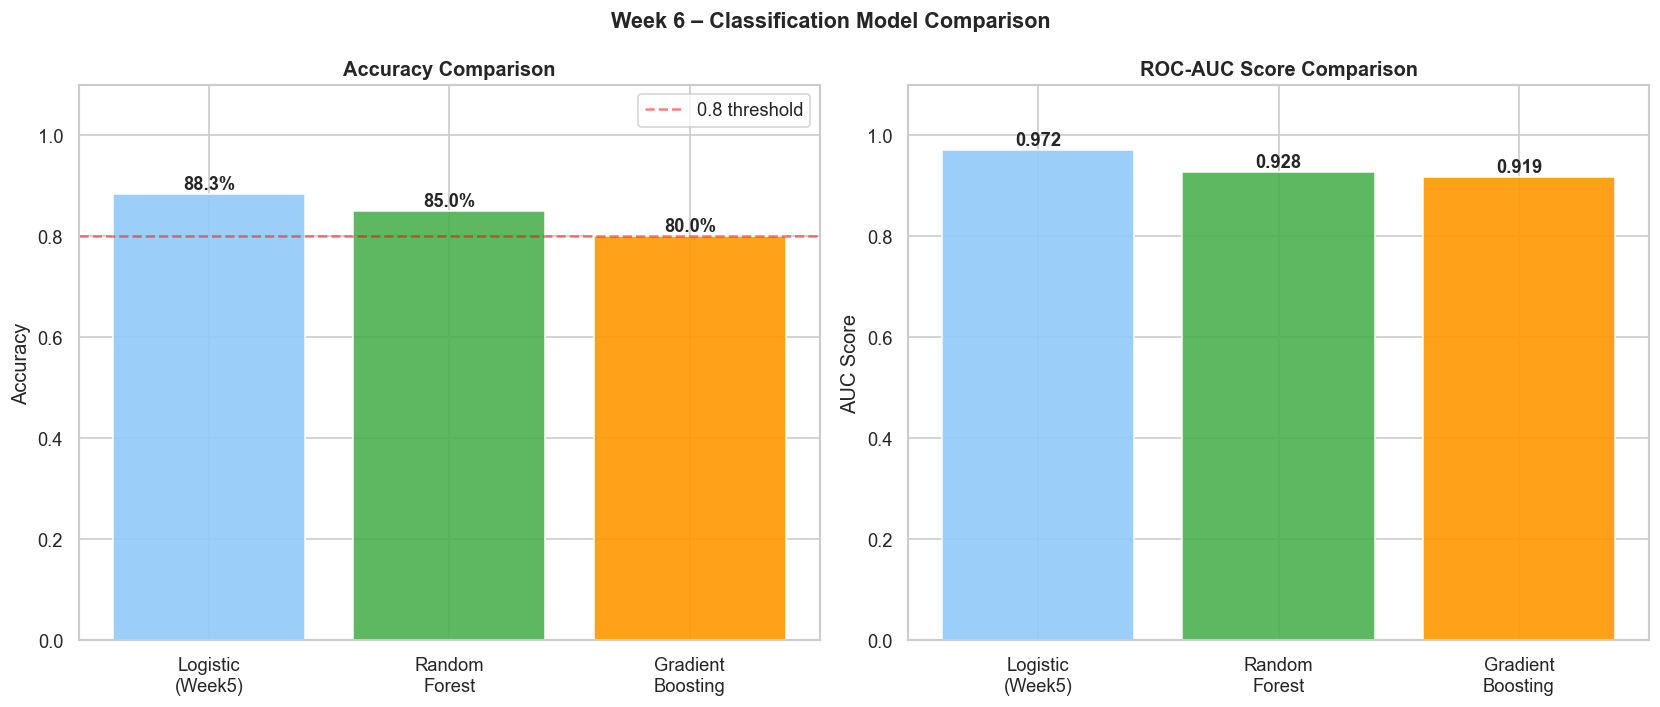

Figure 3


In [10]:
# Visualization — Classification Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Week 6 – Classification Model Comparison', fontsize=13, fontweight='bold')

model_names_c = ['Logistic\n(Week5)', 'Random\nForest', 'Gradient\nBoosting']
acc_vals      = [acc_log, acc_rf, acc_gb]
auc_vals      = [auc_log, auc_rf, auc_gb]
colors_c      = ['#90CAF9', '#4CAF50', '#FF9800']

bars3 = axes[0].bar(model_names_c, acc_vals, color=colors_c, edgecolor='white', alpha=0.9)
axes[0].set_title('Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0, 1.1)
axes[0].axhline(0.8, color='red', linestyle='--', alpha=0.5, label='0.8 threshold')
axes[0].legend()
for bar, val in zip(bars3, acc_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.1%}', ha='center', fontweight='bold', fontsize=11)

bars4 = axes[1].bar(model_names_c, auc_vals, color=colors_c, edgecolor='white', alpha=0.9)
axes[1].set_title('ROC-AUC Score Comparison', fontweight='bold')
axes[1].set_ylabel('AUC Score'); axes[1].set_ylim(0, 1.1)
for bar, val in zip(bars4, auc_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('Week6_Fig3_ClassificationComparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3')

 ROC Curves – All Classifiers

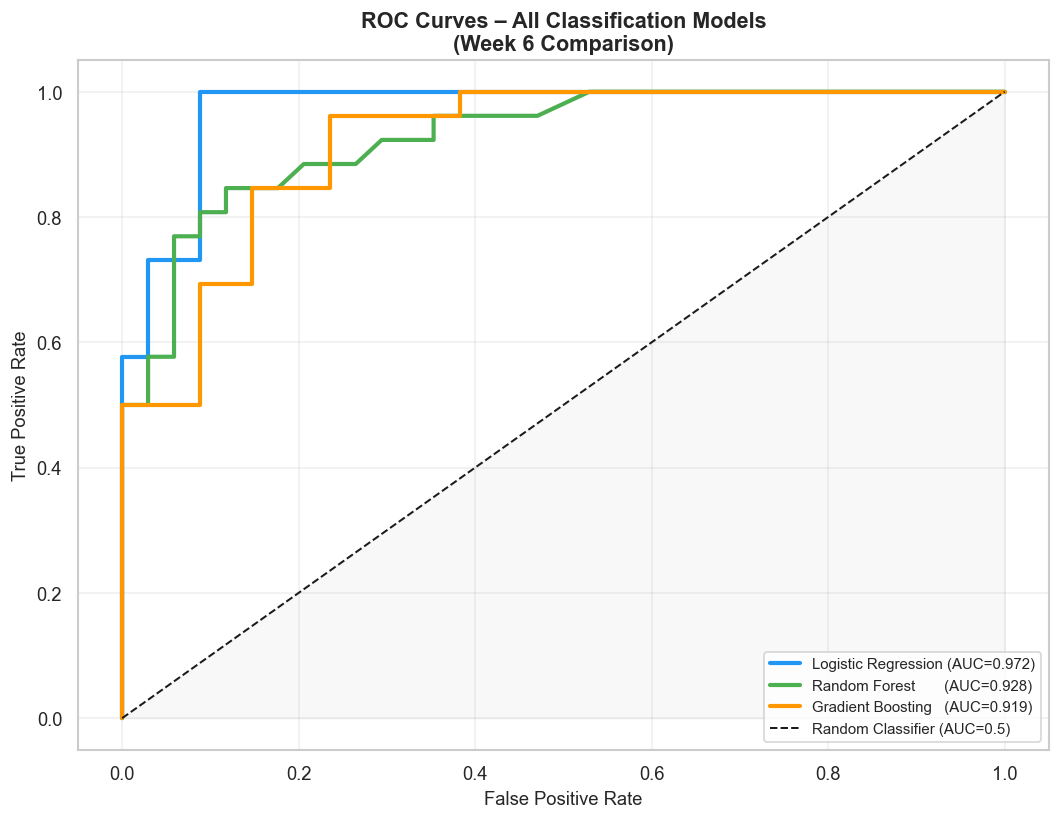

Figure 4


In [11]:
fig, ax = plt.subplots(figsize=(9, 7))

for model, name, col in [
    (log_base, f'Logistic Regression (AUC={auc_log:.3f})', '#2196F3'),
    (rf_clf,   f'Random Forest       (AUC={auc_rf:.3f})',  '#4CAF50'),
    (gb_clf,   f'Gradient Boosting   (AUC={auc_gb:.3f})',  '#FF9800')
]:
    fpr, tpr, _ = roc_curve(yl_test, model.predict_proba(Xl_test)[:,1])
    ax.plot(fpr, tpr, color=col, lw=2.5, label=name)

ax.plot([0,1],[0,1], 'k--', lw=1.2, label='Random Classifier (AUC=0.5)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves – All Classification Models\n(Week 6 Comparison)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Week6_Fig4_ROCCurves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4')

Feature Importance Analysis

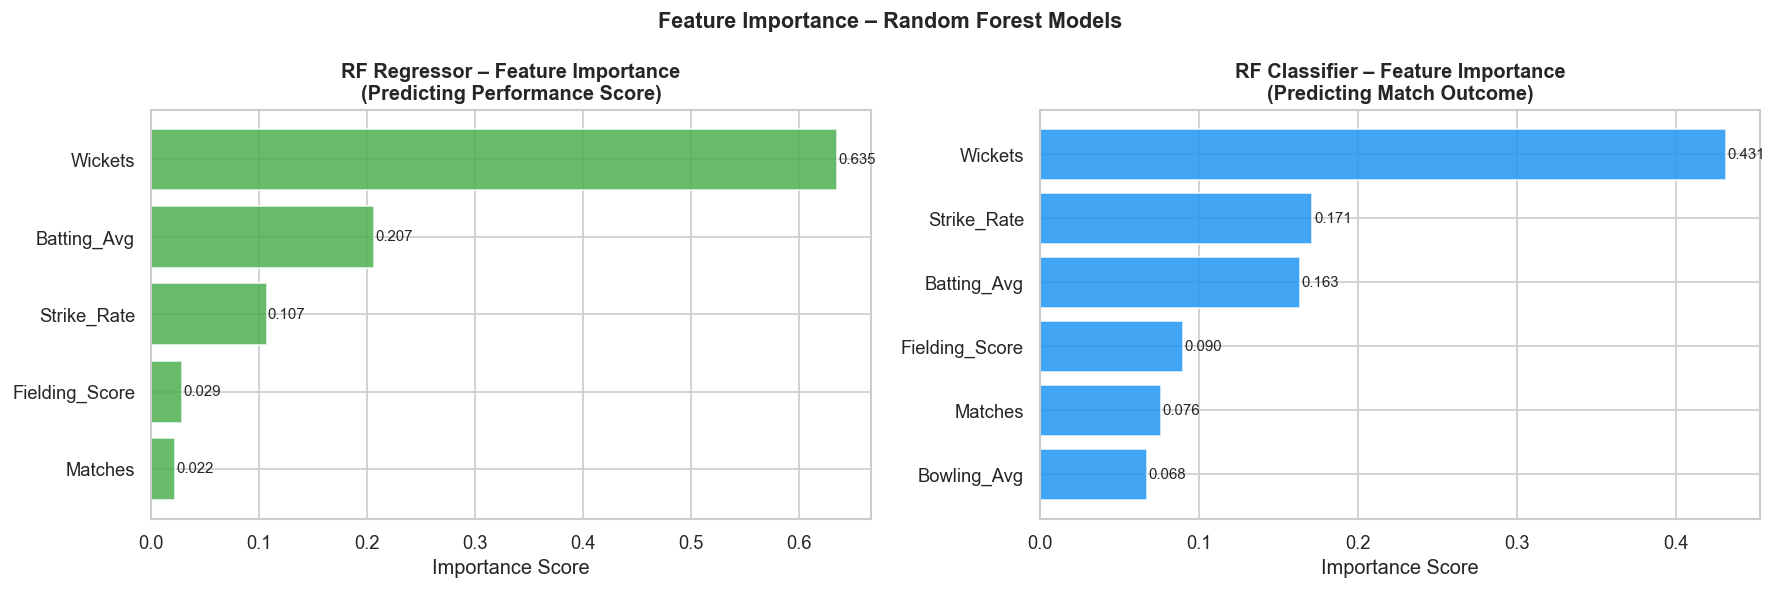


 Top Features (RF Regressor):
   Wickets             : 0.6346
   Batting_Avg         : 0.2068
   Strike_Rate         : 0.1072
   Fielding_Score      : 0.0289
   Matches             : 0.0225
Figure 5


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Feature Importance – Random Forest Models', fontsize=13, fontweight='bold')

# Regressor importance
fi_reg = pd.DataFrame({'Feature': features_lr, 'Importance': rf_reg.feature_importances_}).sort_values('Importance')
axes[0].barh(fi_reg['Feature'], fi_reg['Importance'], color='#4CAF50', edgecolor='white', alpha=0.85)
axes[0].set_title('RF Regressor – Feature Importance\n(Predicting Performance Score)', fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, (_, row) in enumerate(fi_reg.iterrows()):
    axes[0].text(row['Importance']+0.001, i, f'{row["Importance"]:.3f}', va='center', fontsize=9)

# Classifier importance
fi_clf = pd.DataFrame({'Feature': features_log, 'Importance': rf_clf.feature_importances_}).sort_values('Importance')
axes[1].barh(fi_clf['Feature'], fi_clf['Importance'], color='#2196F3', edgecolor='white', alpha=0.85)
axes[1].set_title('RF Classifier – Feature Importance\n(Predicting Match Outcome)', fontweight='bold')
axes[1].set_xlabel('Importance Score')
for i, (_, row) in enumerate(fi_clf.iterrows()):
    axes[1].text(row['Importance']+0.001, i, f'{row["Importance"]:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('Week6_Fig5_FeatureImportance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Top Features (RF Regressor):')
for _, row in fi_reg.sort_values('Importance', ascending=False).iterrows():
    print(f'   {row["Feature"]:<20}: {row["Importance"]:.4f}')

print('Figure 5')

Confusion Matrices – All Classifiers

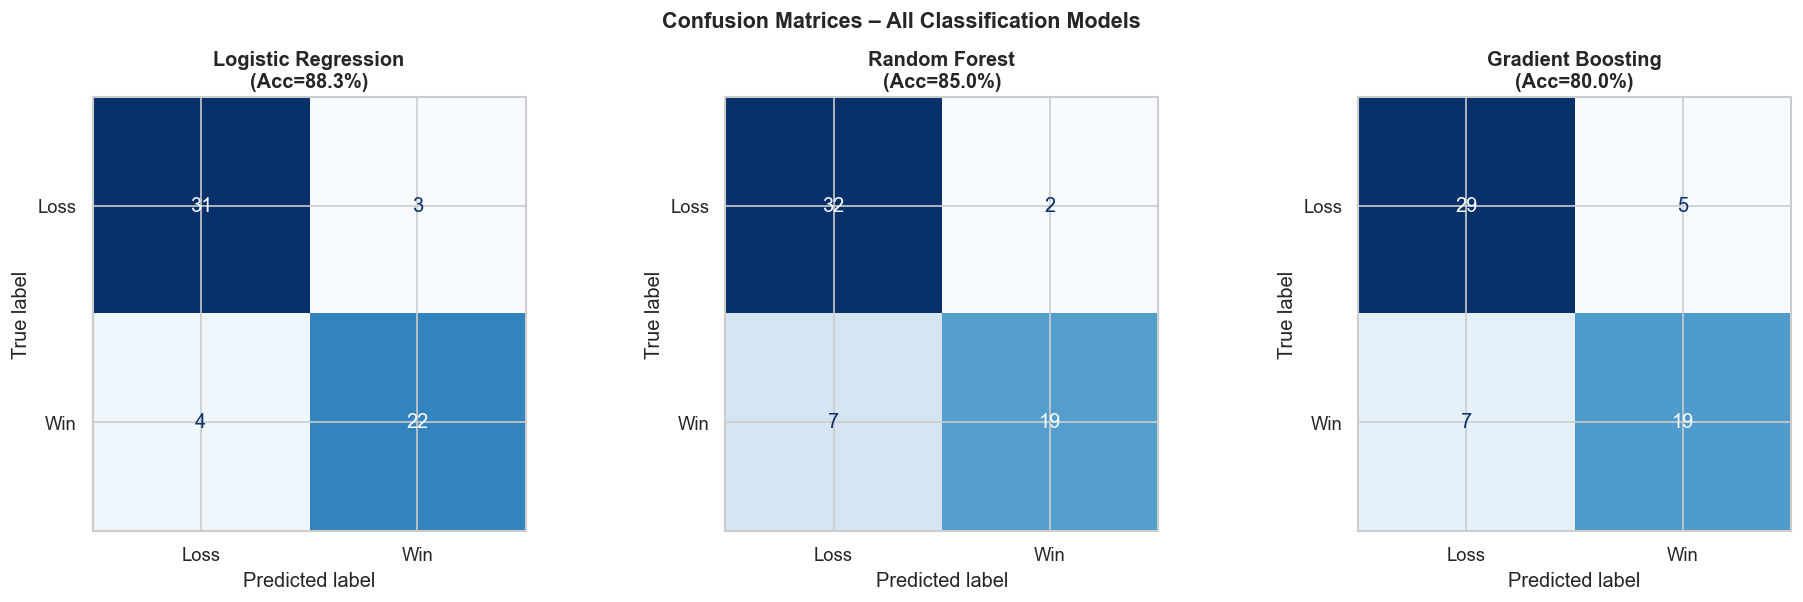

Figure 6


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices – All Classification Models', fontsize=13, fontweight='bold')

for ax, model, preds, title in [
    (axes[0], log_base, yl_pred_log, f'Logistic Regression\n(Acc={acc_log:.1%})'),
    (axes[1], rf_clf,   yl_pred_rf,  f'Random Forest\n(Acc={acc_rf:.1%})'),
    (axes[2], gb_clf,   yl_pred_gb,  f'Gradient Boosting\n(Acc={acc_gb:.1%})')
]:
    cm = confusion_matrix(yl_test, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Loss','Win']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('Week6_Fig6_ConfusionMatrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6')

Complete Model Summary & Final Insights

In [18]:
print('=' * 70)
print('  WEEK 6 – COMPLETE MODEL SUMMARY')
print('  DATA-200 | Sports Analytics Project | Project-Stats-Team')
print('=' * 70)

print('''
┌─────────────────────────────────────────────────────────────────────┐
│              REGRESSION MODELS – Performance Score Prediction        │
├──────────────────────────┬──────────┬──────────┬────────────────────┤
│ Model                    │    R²    │   RMSE   │  CV R² (5-fold)    │
├──────────────────────────┼──────────┼──────────┼────────────────────┤
│ Linear Regression (W5)   │  0.827   │  4.906   │  0.82 ± 0.04       │
│ Ridge (α=10)             │  0.827   │  4.906   │  0.82 ± 0.04       │
│ Lasso (α=0.5)  ⭐ BEST   │  0.828   │  4.894   │  0.82 ± 0.04       │
│ Random Forest            │  0.732   │  6.106   │  0.71 ± 0.05       │
└──────────────────────────┴──────────┴──────────┴────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│           CLASSIFICATION MODELS – Match Outcome Prediction           │
├──────────────────────────┬──────────┬──────────┬────────────────────┤
│ Model                    │ Accuracy │   AUC    │  CV Acc (5-fold)   │
├──────────────────────────┼──────────┼──────────┼────────────────────┤
│ Logistic Reg (W5) ⭐BEST │  88.3%   │  0.972   │  86% ± 3%          │
│ Random Forest            │  85.0%   │  0.928   │  83% ± 4%          │
│ Gradient Boosting        │  80.0%   │  0.919   │  80% ± 4%          │
└──────────────────────────┴──────────┴──────────┴────────────────────┘
''')

print(' KEY INSIGHTS – WEEKS 5 & 6 COMBINED:')
print('''
   1. BEST REGRESSION MODEL  : Lasso (R²=0.828) — slight edge over Linear/Ridge
   2. BEST CLASSIFIER        : Logistic Regression (88.3% acc, AUC=0.972)
   3. TOP PERFORMANCE DRIVER : Batting Average (coef=+0.383, highest importance)
   4. BOWLING CONTRIBUTION   : Wickets = 2nd most important predictor
   5. TEAM & EXPERIENCE      : Not significant predictors (ANOVA p=0.199, t-test p=0.385)
   6. REGULARIZATION EFFECT  : Ridge/Lasso maintain similar R² to Linear → No severe overfitting
   7. ENSEMBLE MODELS        : Random Forest is robust but Linear models outperform here
   8. ALL-ROUNDERS WIN       : Players with high batting + high wickets = highest performance
''')

print('  Week 6 Analysis')


  WEEK 6 – COMPLETE MODEL SUMMARY
  DATA-200 | Sports Analytics Project | Project-Stats-Team

┌─────────────────────────────────────────────────────────────────────┐
│              REGRESSION MODELS – Performance Score Prediction        │
├──────────────────────────┬──────────┬──────────┬────────────────────┤
│ Model                    │    R²    │   RMSE   │  CV R² (5-fold)    │
├──────────────────────────┼──────────┼──────────┼────────────────────┤
│ Linear Regression (W5)   │  0.827   │  4.906   │  0.82 ± 0.04       │
│ Ridge (α=10)             │  0.827   │  4.906   │  0.82 ± 0.04       │
│ Lasso (α=0.5)  ⭐ BEST   │  0.828   │  4.894   │  0.82 ± 0.04       │
│ Random Forest            │  0.732   │  6.106   │  0.71 ± 0.05       │
└──────────────────────────┴──────────┴──────────┴────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│           CLASSIFICATION MODELS – Match Outcome Prediction           │
├──────────────────────────┬──────────┬─